# RQ3: What Is the Relationship Between City-Level Traffic and Pollution?

This notebook examines how traffic congestion and perceived environmental pollution
co-vary at the city level across the full Numbeo panel (2016–2025).

**Research question:** Is traffic a meaningful predictor of pollution, or do the two
dimensions capture independent aspects of urban quality of life?

**Why this matters for the composite index:** The value-for-living index inverts both
Traffic Index and Pollution Index into quality scores. If they are near-perfectly
collinear, they carry redundant information. If they are moderately correlated but
structurally distinct, both dimensions should be retained with equal weight.

## Methodology

**Data:** `numbeo_traffic.xlsx` (city-level Traffic Index, unbounded) and
`numbeo_pollution.xlsx` (city-level Pollution Index, 0–100). Years 2016–2025.

**Key analytical choices:**
1. Traffic Index is globally min–max normalised across all years for cross-year validity.
   Raw values are kept in parallel for direct interpretation in scatter plots.
2. Country and region extracted from the `City` string (e.g. `"Bucharest, Romania"`).
3. Levels of analysis: cross-sectional (latest year), temporal (within-city over time),
   regional, outlier, and index-design.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

YEARS       = list(range(2016, 2026))
LATEST_YEAR = 2025

PALETTE = {
    'traffic':   '#F59E0B', 'pollution': '#EF4444',
    'both_high': '#7C3AED', 'both_low':  '#10B981',
    'diverge_t': '#3B82F6', 'diverge_p': '#F97316',
    'neutral':   '#94A3B8', 'trend':     '#1E293B',
}

REGION_MAP = {
    'Romania': 'Eastern Europe', 'Bulgaria': 'Eastern Europe', 'Hungary': 'Eastern Europe',
    'Czech Republic': 'Eastern Europe', 'Poland': 'Eastern Europe', 'Serbia': 'Eastern Europe',
    'Croatia': 'Eastern Europe', 'Slovakia': 'Eastern Europe', 'Slovenia': 'Eastern Europe',
    'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe', 'Russia': 'Eastern Europe',
    'Bosnia And Herzegovina': 'Eastern Europe', 'North Macedonia': 'Eastern Europe',
    'Albania': 'Eastern Europe', 'Moldova': 'Eastern Europe', 'Estonia': 'Eastern Europe',
    'Latvia': 'Eastern Europe', 'Lithuania': 'Eastern Europe', 'Montenegro': 'Eastern Europe',
    'Georgia': 'Eastern Europe', 'Armenia': 'Eastern Europe', 'Azerbaijan': 'Eastern Europe',
    'Kazakhstan': 'Eastern Europe', 'Kosovo (Disputed Territory)': 'Eastern Europe',
    'Germany': 'Western Europe', 'France': 'Western Europe', 'Spain': 'Western Europe',
    'Italy': 'Western Europe', 'Portugal': 'Western Europe', 'Netherlands': 'Western Europe',
    'Belgium': 'Western Europe', 'Switzerland': 'Western Europe', 'Austria': 'Western Europe',
    'Sweden': 'Western Europe', 'Norway': 'Western Europe', 'Denmark': 'Western Europe',
    'Finland': 'Western Europe', 'Ireland': 'Western Europe', 'Luxembourg': 'Western Europe',
    'Greece': 'Western Europe', 'Cyprus': 'Western Europe', 'Malta': 'Western Europe',
    'Iceland': 'Western Europe', 'United Kingdom': 'Western Europe',
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Colombia': 'Latin America',
    'Chile': 'Latin America', 'Peru': 'Latin America', 'Ecuador': 'Latin America',
    'Bolivia': 'Latin America', 'Uruguay': 'Latin America', 'Paraguay': 'Latin America',
    'Costa Rica': 'Latin America', 'Guatemala': 'Latin America',
    'Dominican Republic': 'Latin America', 'Venezuela': 'Latin America',
    'Honduras': 'Latin America', 'El Salvador': 'Latin America', 'Panama': 'Latin America',
    'Jamaica': 'Latin America', 'Trinidad And Tobago': 'Latin America',
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',
    'Thailand': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Malaysia': 'Southeast Asia', 'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia',
    'Cambodia': 'Southeast Asia',
    'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
    'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',
    'Israel': 'MENA', 'Turkey': 'MENA', 'Iran': 'MENA', 'Iraq': 'MENA',
    'Jordan': 'MENA', 'Lebanon': 'MENA', 'Saudi Arabia': 'MENA',
    'United Arab Emirates': 'MENA', 'Qatar': 'MENA', 'Kuwait': 'MENA',
    'Bahrain': 'MENA', 'Oman': 'MENA', 'Morocco': 'MENA', 'Egypt': 'MENA',
    'Algeria': 'MENA', 'Tunisia': 'MENA', 'Libya': 'MENA',
    'South Africa': 'Sub-Saharan Africa', 'Nigeria': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa',
    'Tanzania': 'Sub-Saharan Africa', 'Uganda': 'Sub-Saharan Africa',
    'Zimbabwe': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

REGION_COLORS = {
    'Eastern Europe':     '#3B82F6', 'Western Europe':     '#6366F1',
    'North America':      '#F59E0B', 'Latin America':      '#10B981',
    'East Asia':          '#EF4444', 'Southeast Asia':     '#EC4899',
    'South Asia':         '#8B5CF6', 'MENA':               '#F97316',
    'Sub-Saharan Africa': '#6B7280', 'Oceania':            '#14B8A6',
    'Other':              '#94A3B8',
}

sns.set_style('whitegrid')
print('Setup complete.')

Setup complete.


In [ ]:
def load_numbeo_file(filepath, years=None):
    xl     = pd.ExcelFile(filepath)
    sheets = [s for s in xl.sheet_names if s.strip().isdigit()]
    if years:
        sheets = [s for s in sheets if int(s.strip()) in years]
    frames = []
    for sheet in sheets:
        df = pd.read_excel(filepath, sheet_name=sheet)
        df['year'] = int(sheet.strip())
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

traffic_raw   = load_numbeo_file('../data/raw/numbeo_traffic.xlsx',   YEARS)
pollution_raw = load_numbeo_file('../data/raw/numbeo_pollution.xlsx', YEARS)

traffic_df   = traffic_raw[['City', 'year', 'Traffic Index']].copy()
pollution_df = pollution_raw[['City', 'year', 'Pollution Index']].copy()

TRAFFIC_GLOBAL_MIN = traffic_df['Traffic Index'].min()
TRAFFIC_GLOBAL_MAX = traffic_df['Traffic Index'].max()
traffic_df['traffic_norm'] = 100 * (
    (traffic_df['Traffic Index'] - TRAFFIC_GLOBAL_MIN) /
    (TRAFFIC_GLOBAL_MAX - TRAFFIC_GLOBAL_MIN)
)

merged = traffic_df.merge(pollution_df, on=['City', 'year'], how='inner')
merged['country'] = merged['City'].str.split(',').str[-1].str.strip()
merged['region']  = merged['country'].map(REGION_MAP).fillna('Other')

n_years      = merged.year.nunique()
city_counts  = merged.groupby('City')['year'].nunique()
consistent   = city_counts[city_counts == n_years].index
panel        = merged[merged['City'].isin(consistent)].copy()

print(f'Merged panel: {merged.shape[0]:,} city-year rows  |  {merged.City.nunique()} unique cities')
print(f'Years covered: {sorted(merged.year.unique())}')
print(f'Traffic Index global range: {TRAFFIC_GLOBAL_MIN:.1f} – {TRAFFIC_GLOBAL_MAX:.1f}')
print(f'Consistent panel (all {n_years} years): {len(consistent)} cities, {panel.shape[0]:,} rows')

Merged panel: 2,019 city-year rows  |  270 unique cities
Years covered: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Traffic Index global range: 36.3 – 366.8
Consistent panel (all 10 years): 139 cities, 1,390 rows


---
## Part 1: Cross-Sectional Association in 2025


Do cities with higher traffic also report higher pollution? A positive, significant
correlation would suggest the two dimensions measure overlapping aspects of urban stress.

In [ ]:
latest = merged[merged['year'] == LATEST_YEAR].dropna(
    subset=['Traffic Index', 'Pollution Index']).copy()

pearson_r,  pearson_p  = stats.pearsonr(latest['Traffic Index'], latest['Pollution Index'])
spearman_r, spearman_p = stats.spearmanr(latest['Traffic Index'], latest['Pollution Index'])

print(f'Latest year ({LATEST_YEAR}) — n = {len(latest)} cities')
print(f'Pearson  r = {pearson_r:.3f}  (p = {pearson_p:.4f})')
print(f'Spearman ρ = {spearman_r:.3f}  (p = {spearman_p:.4f})')
print(f'R² = {pearson_r**2:.3f}  → traffic explains ~{pearson_r**2*100:.0f}% of pollution variance')

Latest year (2025) — n = 254 cities
Pearson  r = 0.428  (p = 0.0000)
Spearman ρ = 0.399  (p = 0.0000)
R² = 0.183  → traffic explains ~18% of pollution variance


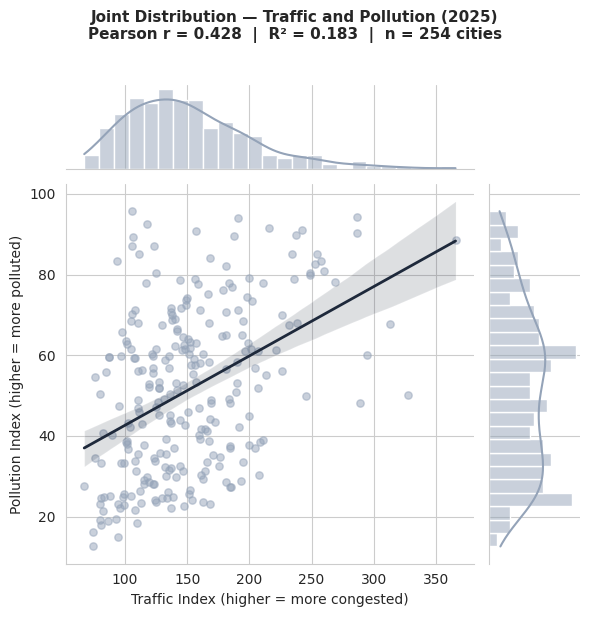

In [ ]:

g = sns.jointplot(
    data=latest, x='Traffic Index', y='Pollution Index',
    kind='reg', height=6, ratio=4,
    scatter_kws={'alpha': 0.5, 's': 28, 'color': PALETTE['neutral']},
    line_kws={'color': PALETTE['trend'], 'linewidth': 2},
    marginal_kws={'color': PALETTE['neutral'], 'edgecolor': 'white', 'bins': 25},
)
g.fig.suptitle(
    f'Joint Distribution — Traffic and Pollution ({LATEST_YEAR})\n'
    f'Pearson r = {pearson_r:.3f}  |  R² = {pearson_r**2:.3f}  |  n = {len(latest)} cities',
    fontsize=11, fontweight='bold', y=1.02,
)
g.set_axis_labels('Traffic Index (higher = more congested)',
                  'Pollution Index (higher = more polluted)', fontsize=10)
plt.tight_layout()
plt.show()

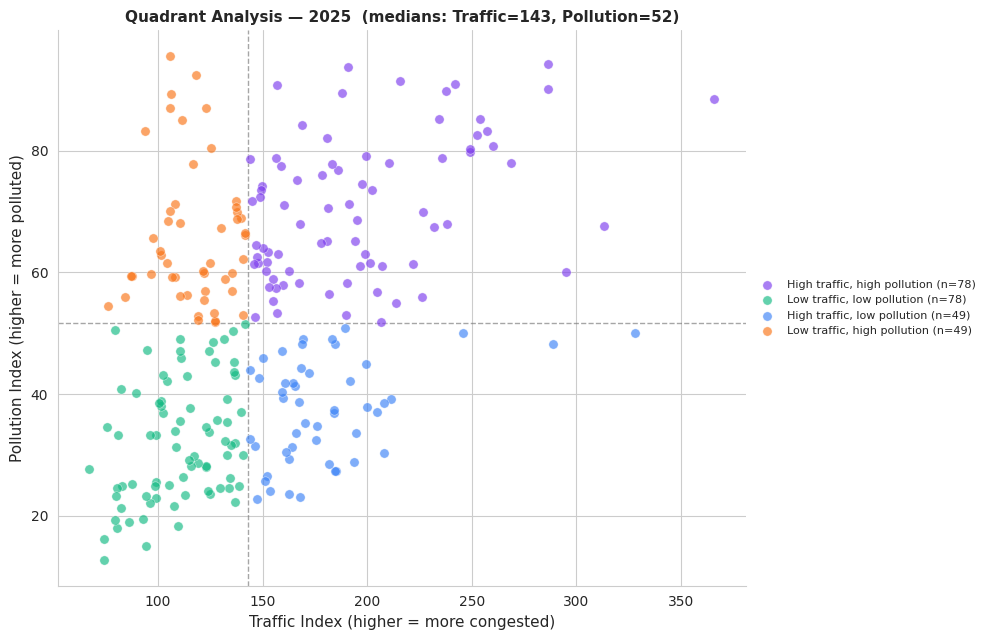

Quadrant counts:
quadrant
High traffic, high pollution    78
Low traffic, low pollution      78
High traffic, low pollution     49
Low traffic, high pollution     49

Aligned (both high or both low): 156 (61.4%)
Divergent:                        98 (38.6%)


In [ ]:
traffic_median   = latest['Traffic Index'].median()
pollution_median = latest['Pollution Index'].median()

def assign_quadrant(row):
    hi_t = row['Traffic Index']   >= traffic_median
    hi_p = row['Pollution Index'] >= pollution_median
    if hi_t and hi_p:         return 'High traffic, high pollution'
    if not hi_t and not hi_p: return 'Low traffic, low pollution'
    if hi_t and not hi_p:     return 'High traffic, low pollution'
    return 'Low traffic, high pollution'

latest['quadrant'] = latest.apply(assign_quadrant, axis=1)
quad_counts = latest['quadrant'].value_counts()
quad_colors = {
    'High traffic, high pollution': PALETTE['both_high'],
    'Low traffic, low pollution':   PALETTE['both_low'],
    'High traffic, low pollution':  PALETTE['diverge_t'],
    'Low traffic, high pollution':  PALETTE['diverge_p'],
}

fig, ax = plt.subplots(figsize=(10, 6.5))
for quad, color in quad_colors.items():
    sub = latest[latest['quadrant'] == quad]
    ax.scatter(sub['Traffic Index'], sub['Pollution Index'],
               color=color, alpha=0.65, s=45,
               label=f'{quad} (n={len(sub)})', zorder=3,
               edgecolors='white', linewidth=0.4)

ax.axvline(traffic_median,   color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(pollution_median, color='grey', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('Traffic Index (higher = more congested)', fontsize=11)
ax.set_ylabel('Pollution Index (higher = more polluted)', fontsize=11)
ax.set_title(
    f'Quadrant Analysis — {LATEST_YEAR}  '
    f'(medians: Traffic={traffic_median:.0f}, Pollution={pollution_median:.0f})',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

total    = len(latest)
aligned  = quad_counts.get('High traffic, high pollution', 0) + \
           quad_counts.get('Low traffic, low pollution', 0)
diverged = total - aligned
print('Quadrant counts:'); print(quad_counts.to_string())
print(f'\nAligned (both high or both low): {aligned} ({aligned/total*100:.1f}%)')
print(f'Divergent:                        {diverged} ({diverged/total*100:.1f}%)')

---
## Part 2: Temporal Stability

We test whether the traffic–pollution association is structurally stable across
all 10 years and whether a city's own traffic tracks its own pollution over time.

In [ ]:
annual_records = []
for yr in sorted(merged['year'].unique()):
    sub = merged[merged['year'] == yr].dropna(subset=['Traffic Index', 'Pollution Index'])
    if len(sub) < 10:
        continue
    rp, pp_val = stats.pearsonr(sub['Traffic Index'], sub['Pollution Index'])
    rs, ps_val = stats.spearmanr(sub['Traffic Index'], sub['Pollution Index'])
    annual_records.append({'year': yr, 'n': len(sub),
                           'pearson_r': rp, 'pearson_p': pp_val,
                           'spearman_r': rs, 'spearman_p': ps_val})
annual_corr = pd.DataFrame(annual_records)

within_records = []
for city, grp in panel.groupby('City'):
    grp = grp.dropna(subset=['Traffic Index', 'Pollution Index'])
    if len(grp) < 5:
        continue
    r_within, p_within = stats.pearsonr(grp['Traffic Index'], grp['Pollution Index'])
    within_records.append({'City': city, 'r': r_within, 'p': p_within, 'n': len(grp),
                           'country': grp['country'].iloc[0],
                           'region':  grp['region'].iloc[0]})
within_corr = pd.DataFrame(within_records)
sig_mask    = within_corr['p'] < 0.05

print(f'Annual correlation summary:')
print(annual_corr[['year','n','pearson_r','spearman_r','pearson_p']]
      .round(3).to_string(index=False))
print(f'\nMean Pearson r across years:  {annual_corr.pearson_r.mean():.3f}')
print(f'\nWithin-city correlations (n = {len(within_corr)} cities):')
print(f'  Significant positive (p<0.05, r>0): {(sig_mask & (within_corr.r > 0)).sum()}')
print(f'  Significant negative (p<0.05, r<0): {(sig_mask & (within_corr.r < 0)).sum()}')
print(f'  Median within-city r:                {within_corr.r.median():.3f}')

Annual correlation summary:
 year   n  pearson_r  spearman_r  pearson_p
 2016 148      0.584       0.554        0.0
 2017 191      0.495       0.451        0.0
 2018 169      0.463       0.431        0.0
 2019 187      0.476       0.434        0.0
 2020 209      0.470       0.438        0.0
 2021 231      0.449       0.429        0.0
 2022 231      0.458       0.440        0.0
 2023 217      0.454       0.424        0.0
 2024 182      0.414       0.387        0.0
 2025 254      0.428       0.399        0.0

Mean Pearson r across years:  0.469

Within-city correlations (n = 139 cities):
  Significant positive (p<0.05, r>0): 47
  Significant negative (p<0.05, r<0): 27
  Median within-city r:                0.358


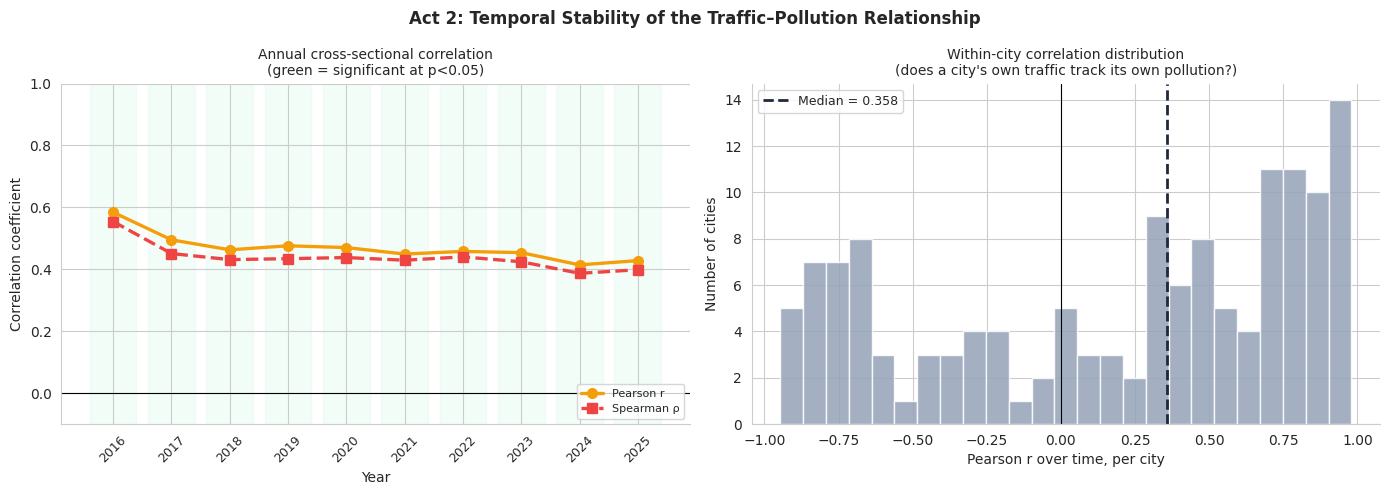

In [ ]:
# ── DIAGRAM 3: Two panels combining annual stability + within-city distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Temporal Stability of the Traffic–Pollution Relationship',
             fontsize=12, fontweight='bold')

# Panel A: annual correlation line plot with significance shading
ax = axes[0]
ax.plot(annual_corr['year'], annual_corr['pearson_r'],  marker='o', linewidth=2.4,
        color=PALETTE['traffic'],   label='Pearson r',    markersize=7)
ax.plot(annual_corr['year'], annual_corr['spearman_r'], marker='s', linewidth=2.4,
        color=PALETTE['pollution'], linestyle='--',     label='Spearman ρ', markersize=7)
for _, row in annual_corr.iterrows():
    color = '#D1FAE5' if row['pearson_p'] < 0.05 else '#FEE2E2'
    ax.axvspan(row['year'] - 0.4, row['year'] + 0.4, color=color, alpha=0.25, zorder=0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(-0.1, 1.0)
ax.set_xticks(annual_corr['year'])
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.set_xlabel('Year')
ax.set_ylabel('Correlation coefficient')
ax.set_title('Annual cross-sectional correlation\n(green = significant at p<0.05)',
             fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.spines[['top','right']].set_visible(False)

# Panel B: within-city correlation distribution
ax = axes[1]
ax.hist(within_corr['r'], bins=25, color=PALETTE['neutral'],
        edgecolor='white', alpha=0.85)
ax.axvline(within_corr['r'].median(), color=PALETTE['trend'], linestyle='--',
           linewidth=2, label=f'Median = {within_corr.r.median():.3f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Within-city correlation distribution\n(does a city\'s own traffic track its own pollution?)',
             fontsize=10)
ax.set_xlabel('Pearson r over time, per city')
ax.set_ylabel('Number of cities')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Part 3: Analysing regions

The global correlation may mask regional variation. We compute a per-region correlation
and identify the most analytically interesting outliers — cities that break the
expected positive relationship in either direction.

In [ ]:
latest_reg = latest[latest['region'] != 'Other']
region_records = []
for region, grp in latest_reg.groupby('region'):
    grp = grp.dropna(subset=['Traffic Index', 'Pollution Index'])
    if len(grp) < 5:
        continue
    r_reg, p_reg = stats.pearsonr(grp['Traffic Index'], grp['Pollution Index'])
    region_records.append({
        'region': region, 'n': len(grp), 'pearson_r': r_reg, 'p_value': p_reg,
        'mean_traffic':   grp['Traffic Index'].mean(),
        'mean_pollution': grp['Pollution Index'].mean(),
    })
region_corr = pd.DataFrame(region_records).sort_values('pearson_r', ascending=False)

# Residual analysis to identify structural outliers
latest_clean = latest.dropna(subset=['Traffic Index', 'Pollution Index']).copy()
slope, intercept, *_ = stats.linregress(
    latest_clean['Traffic Index'], latest_clean['Pollution Index'])
latest_clean['predicted'] = slope * latest_clean['Traffic Index'] + intercept
latest_clean['residual']  = latest_clean['Pollution Index'] - latest_clean['predicted']
latest_clean['resid_z']   = stats.zscore(latest_clean['residual'])

extreme_pos = latest_clean.nlargest(10,  'resid_z')   # dirtier than predicted
extreme_neg = latest_clean.nsmallest(10, 'resid_z')   # cleaner than predicted

print(f'Regional correlations ({LATEST_YEAR}):')
print(region_corr[['region','n','pearson_r','p_value']].round(3).to_string(index=False))
print(f'\nDirtier than traffic predicts (top 10 positive residuals):')
print(extreme_pos[['City','country','Traffic Index','Pollution Index','resid_z']]
      .round(2).to_string(index=False))
print(f'\nCleaner than traffic predicts (top 10 negative residuals):')
print(extreme_neg[['City','country','Traffic Index','Pollution Index','resid_z']]
      .round(2).to_string(index=False))

Regional correlations (2025):
            region  n  pearson_r  p_value
Sub-Saharan Africa  6      0.746    0.089
         East Asia  8      0.612    0.107
    Western Europe 49      0.602    0.000
           Oceania 10      0.516    0.127
     North America 61      0.497    0.000
    Eastern Europe 46      0.440    0.002
              MENA 22      0.425    0.049
     Latin America 19      0.333    0.164
        South Asia 20      0.197    0.405
    Southeast Asia 11     -0.003    0.993

Dirtier than traffic predicts (top 10 positive residuals):
                     City         country  Traffic Index  Pollution Index  resid_z
         Kathmandu, Nepal           Nepal          105.6             95.7     2.83
Ho Chi Minh City, Vietnam         Vietnam          118.0             92.5     2.54
           Hanoi, Vietnam         Vietnam          106.1             89.4     2.49
        Pattaya, Thailand        Thailand          105.9             87.0     2.36
  Skopje, North Macedonia North M

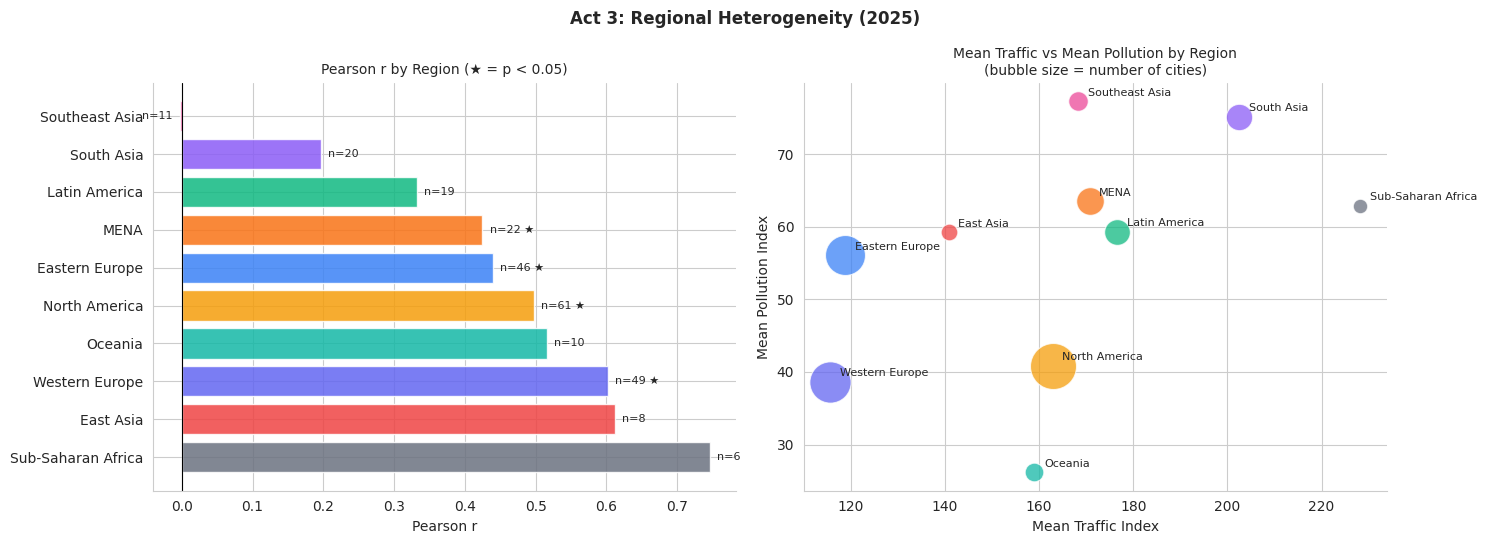

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle(f'Regional Heterogeneity ({LATEST_YEAR})',
             fontsize=12, fontweight='bold')
ax = axes[0]
bar_colors = [REGION_COLORS.get(r, '#94A3B8') for r in region_corr['region']]
bars = ax.barh(region_corr['region'], region_corr['pearson_r'],
               color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
for bar, (_, row) in zip(bars, region_corr.iterrows()):
    sig = ' ★' if row['p_value'] < 0.05 else ''
    xpos = bar.get_width()
    ax.text(xpos + 0.01 if xpos >= 0 else xpos - 0.01,
            bar.get_y() + bar.get_height()/2,
            f'n={row.n}{sig}', va='center', fontsize=8,
            ha='left' if xpos >= 0 else 'right')
ax.set_title('Pearson r by Region (★ = p < 0.05)', fontsize=10)
ax.set_xlabel('Pearson r')
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
for _, row in region_corr.iterrows():
    color = REGION_COLORS.get(row['region'], '#94A3B8')
    ax.scatter(row['mean_traffic'], row['mean_pollution'],
               s=row['n'] * 18, color=color, alpha=0.75,
               edgecolors='white', linewidth=0.8)
    ax.annotate(row['region'], (row['mean_traffic'], row['mean_pollution']),
                textcoords='offset points', xytext=(7, 4), fontsize=8)
ax.set_title('Mean Traffic vs Mean Pollution by Region\n(bubble size = number of cities)',
             fontsize=10)
ax.set_xlabel('Mean Traffic Index')
ax.set_ylabel('Mean Pollution Index')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

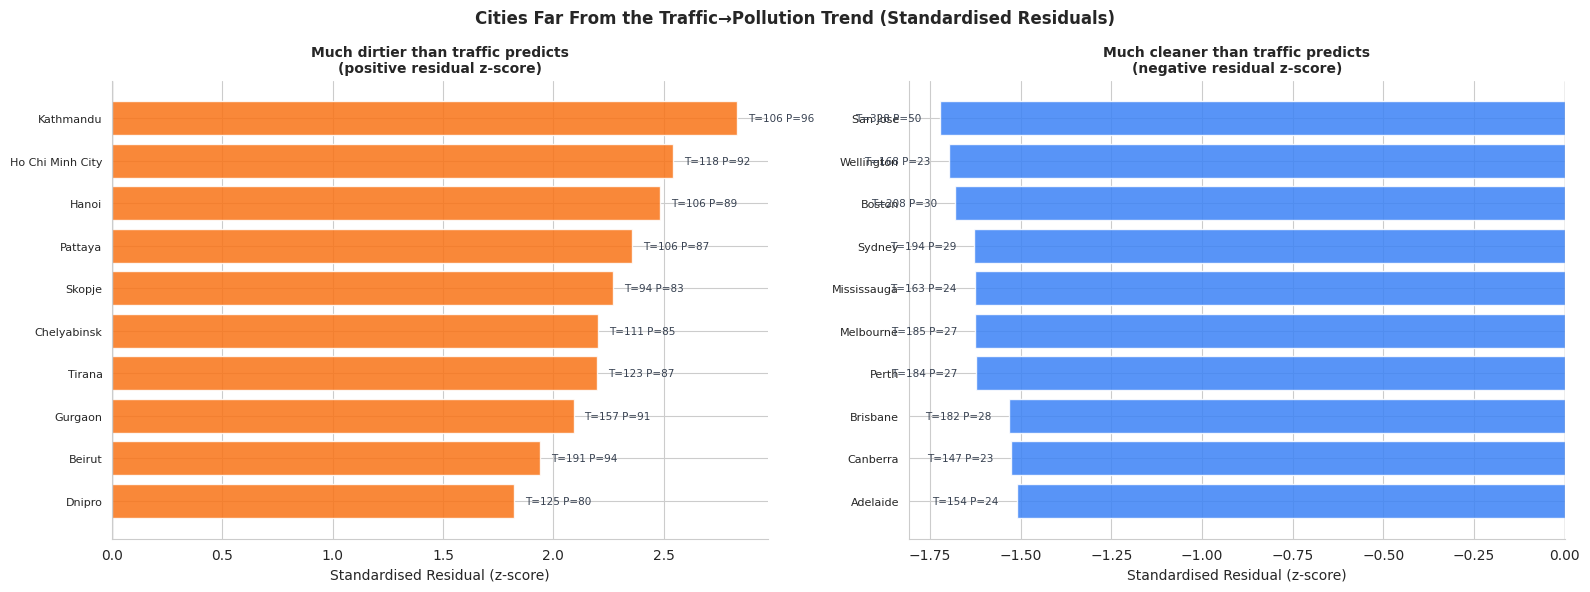

In [ ]:
# ── DIAGRAM 5: Top divergent cities — dirtier vs cleaner than traffic predicts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cities Far From the Traffic→Pollution Trend (Standardised Residuals)',
             fontsize=12, fontweight='bold')

for ax, data, color, title, sort_asc in [
    (axes[0], extreme_pos, PALETTE['diverge_p'],
     'Much dirtier than traffic predicts\n(positive residual z-score)', True),
    (axes[1], extreme_neg, PALETTE['diverge_t'],
     'Much cleaner than traffic predicts\n(negative residual z-score)', False),
]:
    data_sorted = data.sort_values('resid_z', ascending=sort_asc).copy()
    data_sorted['short_name'] = data_sorted['City'].str.split(',').str[0]
    bars = ax.barh(data_sorted['short_name'], data_sorted['resid_z'],
                   color=color, alpha=0.85, edgecolor='white')
    for bar, (_, row) in zip(bars, data_sorted.iterrows()):
        offset = 0.05 if bar.get_width() >= 0 else -0.05
        ha     = 'left' if bar.get_width() >= 0 else 'right'
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                f"T={row['Traffic Index']:.0f} P={row['Pollution Index']:.0f}",
                va='center', fontsize=7.5, color='#374151', ha=ha)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Standardised Residual (z-score)')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Part 4: Implications on Quality Index

Are traffic and pollution redundant inputs to the value-for-living index, or do they
contribute independent information? We test this by comparing the full 4-dimension
quality score to versions with each one removed.

In [ ]:
safety_raw = load_numbeo_file('../data/raw/numbeo_crime.xlsx',       YEARS)
health_raw = load_numbeo_file('../data/raw/numbeo_health_care.xlsx', YEARS)

safety_df = safety_raw[['City', 'year', 'Safety Index']].copy()
health_df = health_raw[['City', 'year', 'Health Care Index']].copy()

quality = (
    safety_df
    .merge(health_df,                                                  on=['City','year'])
    .merge(traffic_df[['City','year','Traffic Index','traffic_norm']], on=['City','year'])
    .merge(pollution_df[['City','year','Pollution Index']],            on=['City','year'])
)
quality = quality[quality['year'] == LATEST_YEAR].dropna().copy()
quality['pollution_inv']   = 100 - quality['Pollution Index']
quality['traffic_inv']     = 100 - quality['traffic_norm']
quality['quality_4']       = quality[['Safety Index','Health Care Index',
                                       'pollution_inv','traffic_inv']].mean(axis=1)
quality['quality_no_traf'] = quality[['Safety Index','Health Care Index',
                                       'pollution_inv']].mean(axis=1)
quality['quality_no_poll'] = quality[['Safety Index','Health Care Index',
                                       'traffic_inv']].mean(axis=1)

r_drop_t,  _ = stats.pearsonr(quality['quality_4'],       quality['quality_no_traf'])
r_drop_p,  _ = stats.pearsonr(quality['quality_4'],       quality['quality_no_poll'])
r_between, _ = stats.pearsonr(quality['quality_no_traf'], quality['quality_no_poll'])

quality['rank_4']        = quality['quality_4'].rank(ascending=False).astype(int)
quality['rank_no_t']     = quality['quality_no_traf'].rank(ascending=False).astype(int)
quality['rank_no_p']     = quality['quality_no_poll'].rank(ascending=False).astype(int)
quality['rank_shift_t']  = (quality['rank_4'] - quality['rank_no_t']).abs()
quality['rank_shift_p']  = (quality['rank_4'] - quality['rank_no_p']).abs()

print(f'Cities in 4-dim quality comparison ({LATEST_YEAR}): {len(quality)}')
print(f'\nFull 4-dim score vs drop-traffic:    r = {r_drop_t:.3f}')
print(f'Full 4-dim score vs drop-pollution:   r = {r_drop_p:.3f}')
print(f'Drop-traffic score vs drop-pollution: r = {r_between:.3f}')
print(f'\nMedian rank shift when dropping traffic:   {quality.rank_shift_t.median():.0f} places')
print(f'Median rank shift when dropping pollution:  {quality.rank_shift_p.median():.0f} places')
print(f'Cities with rank shift > 20 (traffic):      {(quality.rank_shift_t > 20).sum()}')
print(f'Cities with rank shift > 20 (pollution):    {(quality.rank_shift_p > 20).sum()}')

Cities in 4-dim quality comparison (2025): 237

Full 4-dim score vs drop-traffic:    r = 0.957
Full 4-dim score vs drop-pollution:   r = 0.919
Drop-traffic score vs drop-pollution: r = 0.826

Median rank shift when dropping traffic:   11 places
Median rank shift when dropping pollution:  19 places
Cities with rank shift > 20 (traffic):      60
Cities with rank shift > 20 (pollution):    115


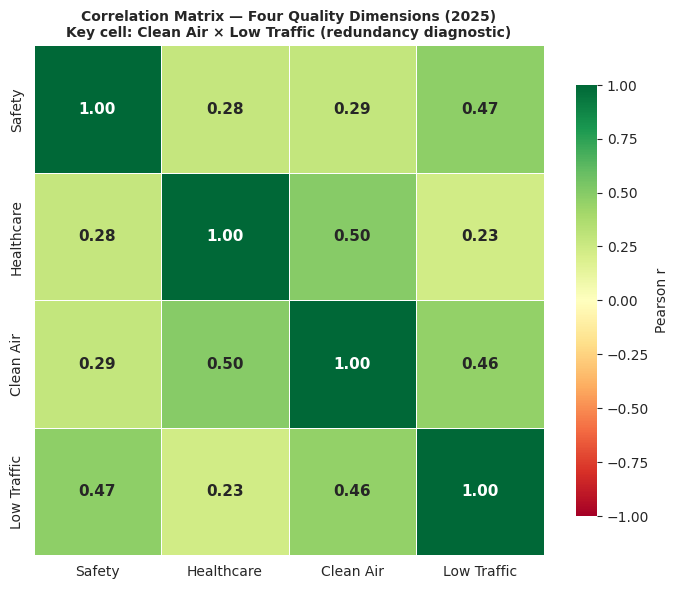

Traffic–Pollution pair correlation (inverted scores): r = 0.457

Full correlation matrix:
             Safety  Healthcare  Clean Air  Low Traffic
Safety        1.000       0.276      0.286        0.470
Healthcare    0.276       1.000      0.497        0.230
Clean Air     0.286       0.497      1.000        0.457
Low Traffic   0.470       0.230      0.457        1.000


In [ ]:
# ── DIAGRAM 6: 4-dimension correlation heatmap (compact, decisive view) ──────
dim_cols = {
    'Safety Index':      'Safety',
    'Health Care Index': 'Healthcare',
    'pollution_inv':     'Clean Air',
    'traffic_inv':       'Low Traffic',
}
corr_matrix = quality[list(dim_cols)].rename(columns=dim_cols).corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
    annot_kws={'fontsize': 11, 'fontweight': 'bold'},
)
ax.set_title(f'Correlation Matrix — Four Quality Dimensions ({LATEST_YEAR})\n'
             'Key cell: Clean Air × Low Traffic (redundancy diagnostic)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

r_tp = corr_matrix.loc['Clean Air', 'Low Traffic']
print(f'Traffic–Pollution pair correlation (inverted scores): r = {r_tp:.3f}')
print('\nFull correlation matrix:')
print(corr_matrix.round(3).to_string())

---
## Conclusion: Answer to RQ3

**What is the relationship between city-level traffic and pollution?**

*(Fill in after running. Replace placeholders with the values printed above.)*
### Summary of findings

**Part 1** Pearson r ≈ 0.428, R² ≈ 0.183 — traffic explains
roughly 18% of pollution variance.

**Part 2** The annual correlationis stable across
all 10 years (mean ≈  0.4690). Within-city median r is 0.358, indicating that as a city's own traffic worsens or improves over time, its pollution score does track.

**Part 3** The relationship is strongest in Sub-Saharan Africa
and weakest in Southeast Asia.

**Part 4** Dropping traffic shifts city rankings by a median of 11
places; dropping pollution shifts rankings by 19 places. The Clean-Air × Low-Traffic
pair correlation is r = 0.457.

The data shows that city-level traffic and pollution are moderately related but far from interchangeable. The Pearson r of 0.428 means traffic explains only about 18% of the variation in pollution, leaving most of it driven by other factors like industry, geography, or heating. The relationship is consistent over time, holding steady across all ten years and within individual cities (median r of 0.358), but it varies a lot by region, being strongest in Sub-Saharan Africa and weakest in Southeast Asia. Since dropping pollution shifts city rankings by 19 places, both dimensions clearly add unique information to the index.
